Imports

In [1]:
!pip install networkx
!pip install pennylane
!pip install pandas


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [7]:
# Enable automatic reloading of imported modules
%load_ext autoreload
%autoreload 2

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

# Import the core logic from your unified engine
from l_vqe_engine import (
    build_k_community_hamiltonian,
    best_known_community_cost,
    simulate_one_vqe,
    simulate_one_lvqe,
    total_qubits
)

CONFIG = {
    "n_seeds": 3,             # paper: 10
    "k_communities": 4,       # ceil(log2 4) = 2 qubits per node
    "optimizer": "SMO",       # paper advocates SMO; "COBYLA" also supported
    "shots": None,            # None = exact energy (Tables 7-8); 2000 = finite samples (Tables 3-4)
    "evals_per_layer": 600,   # L-VQE per-layer budget -> ~3000 total (600+600+1800)
    "vqe_budget": 3000,       # VQE total budget, matched to L-VQE's total
    "device": "lightning.qubit",
}

RAW_CSV = Path("lvqe_vs_vqe_raw.csv")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
def build_graph_suite():
    return [
        ("caveman",  nx.relaxed_caveman_graph(l=4, k=2, p=0.1, seed=0)),
        ("gaussian", nx.gaussian_random_partition_graph(n=8, s=2, v=2,
                                                        p_in=0.9, p_out=0.1, seed=0)),
        ("random_p", nx.random_partition_graph([2, 2, 2, 2], 0.9, 0.1, seed=0)),
        ("windmill", nx.windmill_graph(n=3, k=3)),
        ("gnp",      nx.erdos_renyi_graph(n=8, p=0.5, seed=42)),
        ("power",    nx.powerlaw_cluster_graph(n=8, m=2, p=0.5, seed=0)),
    ]

for name, G in build_graph_suite():
    n = G.number_of_nodes()
    print(f"{name:10s} nodes={n}  qubits={total_qubits(n, CONFIG['k_communities'])}")

caveman    nodes=8  qubits=16
gaussian   nodes=8  qubits=16
random_p   nodes=8  qubits=16
windmill   nodes=7  qubits=14
gnp        nodes=8  qubits=16
power      nodes=8  qubits=16


In [9]:
def run_lvqe_vs_vqe(graph_name, G, cfg):
    records = []
    n_nodes = G.number_of_nodes()
    n_q = total_qubits(n_nodes, cfg["k_communities"])

    print(f"\n{'='*60}\nGraph: {graph_name} | nodes={n_nodes} | qubits={n_q}")
    c_bkv = best_known_community_cost(G, k=cfg["k_communities"])
    print(f"  C_bkv = {c_bkv:.6f}")
    H = build_k_community_hamiltonian(G, cfg["k_communities"])

    for seed in range(cfg["n_seeds"]):
        print(f"\n  Seed {seed+1}/{cfg['n_seeds']}")

        # --- L-VQE: ansatz grown to 0, 1, 2 layers ---
        for max_l in [0, 1, 2]:
            res = simulate_one_lvqe(
                n_q=n_q, H=H, max_layers=max_l, shots=cfg["shots"],
                max_iter_per_layer=cfg["evals_per_layer"],
                rng=np.random.default_rng(seed),
                device_name=cfg["device"], optimizer=cfg["optimizer"],
            )
            records.append({"graph": graph_name, "seed": seed,
                            "algorithm": "L-VQE", "n_layers": max_l,
                            "rho": -res["final_cost"] / c_bkv})
            print(f"    done L-VQE  max_layers={max_l}")

        # --- VQE: fixed ansatz, full budget ---
        for n_l in [1, 2]:
            res = simulate_one_vqe(
                n_q=n_q, H=H, n_layers=n_l, shots=cfg["shots"],
                max_evals=cfg["vqe_budget"],
                rng=np.random.default_rng(seed),
                device_name=cfg["device"], optimizer=cfg["optimizer"],
            )
            records.append({"graph": graph_name, "seed": seed,
                            "algorithm": "VQE", "n_layers": n_l,
                            "rho": -res["final_cost"] / c_bkv})
            print(f"    done VQE    n_layers={n_l}")

    return pd.DataFrame(records)

In [10]:
all_results = []
for graph_name, G in build_graph_suite():
    all_results.append(run_lvqe_vs_vqe(graph_name, G, CONFIG))
    pd.concat(all_results, ignore_index=True).to_csv(RAW_CSV, index=False)

full_df = pd.concat(all_results, ignore_index=True)
print(f"\nSaved {len(full_df)} rows to {RAW_CSV}")


Graph: caveman | nodes=8 | qubits=16
  C_bkv = 0.750000

  Seed 1/3
  Layer 0  (16 params) ... cost = -0.625000
    done L-VQE  max_layers=0
  Layer 0  (16 params) ... cost = -0.625000
  Layer 1  (76 params) ... cost = -0.750000
    done L-VQE  max_layers=1
  Layer 0  (16 params) ... cost = -0.625000
  Layer 1  (76 params) ... cost = -0.750000
  Layer 2  (136 params) ... cost = -0.750000
    done L-VQE  max_layers=2
    done VQE    n_layers=1
    done VQE    n_layers=2

  Seed 2/3
  Layer 0  (16 params) ... cost = -0.750000
    done L-VQE  max_layers=0
  Layer 0  (16 params) ... cost = -0.750000
  Layer 1  (76 params) ... cost = -0.750000
    done L-VQE  max_layers=1
  Layer 0  (16 params) ... cost = -0.750000
  Layer 1  (76 params) ... cost = -0.750000
  Layer 2  (136 params) ... cost = -0.750000
    done L-VQE  max_layers=2
    done VQE    n_layers=1
    done VQE    n_layers=2

  Seed 3/3
  Layer 0  (16 params) ... cost = -0.625000
    done L-VQE  max_layers=0
  Layer 0  (16 params)

In [11]:
def pivot(df, values, agg):
    g = df.groupby(["graph", "algorithm", "n_layers"])["rho"].agg(agg).reset_index()
    vqe = g[g["algorithm"] == "VQE"].pivot(index="graph", columns="n_layers", values="rho")
    vqe.columns = [f"VQE_{c}L" for c in vqe.columns]
    lvqe = g[g["algorithm"] == "L-VQE"].pivot(index="graph", columns="n_layers", values="rho")
    lvqe.columns = [f"LVQE_{c}L" for c in lvqe.columns]
    return pd.concat([vqe, lvqe], axis=1).round(2)

best_table = pivot(full_df, "rho", "max")
avg_table  = pivot(full_df, "rho", "mean")
std_table  = pivot(full_df, "rho", "std")

print("Best approximation ratio (cf. Table 3/7):")
display(best_table)
print("\nAverage ± std (cf. Table 4/8):")
display(avg_table.astype(str) + " ± " + std_table.astype(str))

best_table.to_csv("lvqe_vs_vqe_best.csv")
avg_table.to_csv("lvqe_vs_vqe_avg.csv")

Best approximation ratio (cf. Table 3/7):


,VQE_1L,VQE_2L,LVQE_0L,LVQE_1L,LVQE_2L
graph,,,,,
caveman,1.0,1.0,1.0,1.0,1.0
gaussian,1.0,1.0,1.0,1.0,1.0
gnp,1.0,1.0,1.0,1.0,1.0
power,1.0,1.0,1.0,1.0,1.0
random_p,1.0,1.0,1.0,1.0,1.0
windmill,1.0,1.0,1.0,1.0,1.0



Average ± std (cf. Table 4/8):


,VQE_1L,VQE_2L,LVQE_0L,LVQE_1L,LVQE_2L
graph,,,,,
caveman,1.0 ± 0.0,1.0 ± 0.0,0.89 ± 0.1,1.0 ± 0.0,1.0 ± 0.0
gaussian,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0
gnp,0.97 ± 0.06,0.97 ± 0.06,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0
power,0.8 ± 0.21,0.84 ± 0.27,0.8 ± 0.21,0.8 ± 0.21,0.8 ± 0.21
random_p,1.0 ± 0.0,1.0 ± 0.0,0.89 ± 0.1,1.0 ± 0.0,1.0 ± 0.0
windmill,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0


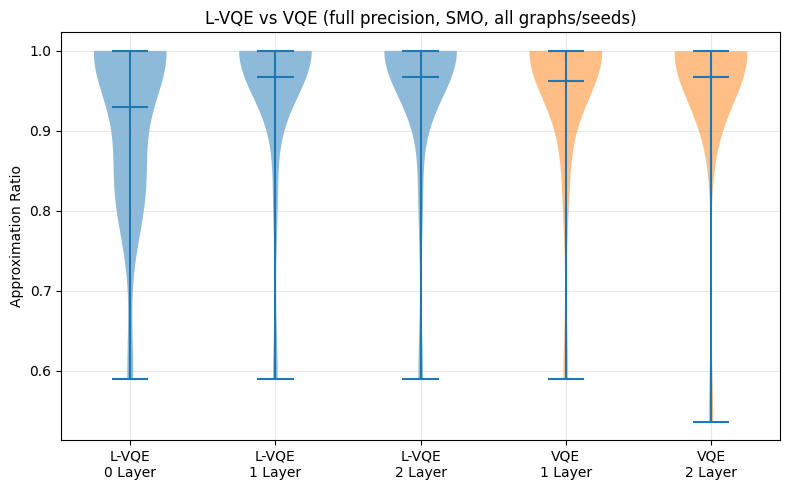

In [12]:
groups = [("L-VQE", 0), ("L-VQE", 1), ("L-VQE", 2), ("VQE", 1), ("VQE", 2)]
data, labels, colors = [], [], []
for algo, nl in groups:
    vals = full_df[(full_df["algorithm"] == algo) & (full_df["n_layers"] == nl)]["rho"].values
    data.append(vals)
    labels.append(f"{algo}\n{nl} Layer")
    colors.append("tab:blue" if algo == "L-VQE" else "tab:orange")

fig, ax = plt.subplots(figsize=(8, 5))
parts = ax.violinplot(data, showmeans=True, showextrema=True)
for body, c in zip(parts["bodies"], colors):
    body.set_facecolor(c)
    body.set_alpha(0.5)

shots_label = "full precision" if CONFIG["shots"] is None else f"{CONFIG['shots']} shots"
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels)
ax.set_ylabel("Approximation Ratio")
ax.set_title(f"L-VQE vs VQE ({shots_label}, {CONFIG['optimizer']}, all graphs/seeds)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()